In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

### Question 1

In [2]:
def initialize_lattice(N, state = 'random'):
    """Initializes an N x N lattice with spins +1 or -1."""
    if state == 'up':
        return np.ones((N, N), dtype = int)
    return np.random.choice([1, -1], size = (N, N))

In [3]:
def metropolis_step_efficient(lattice, beta, J = 1.0):
    N = lattice.shape[0]
    total_dE = 0
    for _ in range(N * N):
        i, j = np.random.randint(0, N, size = 2)
        s = lattice[i, j]
        nb = (lattice[(i+1) % N, j] + lattice[(i-1) % N, j] +
              lattice[i, (j+1) % N] + lattice[i, (j-1) % N])
        dE = 2 * J * s * nb
        
        if dE <= 0 or np.random.rand() < np.exp(-beta * dE):
            lattice[i, j] *= -1
            total_dE += dE # Track the change!
    return lattice, total_dE

In [4]:
def calculate_energy(lattice, J = 1.0):
    """Calculates total energy of the lattice."""
    N = lattice.shape[0]
    energy = 0
    for i in range(N):
        for j in range(N):
            s = lattice[i, j]
            # Only look at right and down neighbors to avoid double counting
            nb = lattice[(i+1) % N, j] + lattice[i, (j+1) % N]
            energy -= J * s * nb
    return energy

In [5]:
def simulate_ising(N, T, eq_steps = 2000, mc_steps = 5000, skip = 50, J = 1.0):
    """
    Simulates Ising model for a given size N and temperature T.
    Returns lists of energy and magnetization samples.
    """
    beta = 1.0 / T
    lattice = initialize_lattice(N, state = 'up')
    
    # 1. Equilibration Phase
    for _ in range(eq_steps):
        metropolis_step_efficient(lattice, beta, J)
        
    # 2. Measurement Phase
    current_energy = calculate_energy(lattice, J)
    energies = []
    magnetizations = []
    
    for s in range(mc_steps):
        # metropolis_step(lattice, beta)
        lattice, dE_step = metropolis_step_efficient(lattice, beta, J)
        current_energy += dE_step
        
        # Sample every 'skip' steps to reduce autocorrelation
        if s % skip == 0:
            energies.append(current_energy)
            magnetizations.append(np.abs(np.sum(lattice)))
            
    return np.array(energies), np.array(magnetizations)

In [6]:
# Execution for the specific lattice sizes
lattice_sizes = [10, 25, 40]
T_target = 2.0  # Around the MFT predicted Tc

for N in lattice_sizes:
    E_samples, M_samples = simulate_ising(N, T_target)
    avg_m = np.mean(M_samples) / (N*N)
    print(f"Lattice {N}x{N} | Avg |M| per site: {avg_m:.4f}")

Lattice 10x10 | Avg |M| per site: 0.9078
Lattice 25x25 | Avg |M| per site: 0.9089
Lattice 40x40 | Avg |M| per site: 0.9099


### Question 2

In [7]:
# Range of temperatures from 0.2 to 4.0
# We use a finer step near the suspected critical point (2.0 to 3.0)
temperatures = np.concatenate([
    np.arange(0.2, 2.0, 0.2), 
    np.arange(2.0, 3.0, 0.1), 
    np.arange(3.0, 4.0, 0.2)
])

N = 20 # Lattice size (20x20)
avg_energies = []
avg_magnetization = []

print(f"Starting simulation for N={N}...")

for T in temperatures:
    # Run simulation
    E_samples, M_samples = simulate_ising(N, T, eq_steps = 2000, mc_steps = 5000, skip = 50, J = 1.0)
    
    # Calculate averages per site
    # Normalizing by N*N gives us values independent of lattice size
    avg_energies.append(np.mean(E_samples) / (N*N))
    avg_magnetization.append(np.mean(M_samples) / (N*N))
    
    print(f"T: {T:.1f} | <E>: {avg_energies[-1]:.3f} | <|M|>: {avg_magnetization[-1]:.3f}")

Starting simulation for N=20...
T: 0.2 | <E>: -2.000 | <|M|>: 1.000
T: 0.4 | <E>: -2.000 | <|M|>: 1.000
T: 0.6 | <E>: -2.000 | <|M|>: 1.000
T: 0.8 | <E>: -2.000 | <|M|>: 1.000
T: 1.0 | <E>: -1.998 | <|M|>: 0.999
T: 1.2 | <E>: -1.990 | <|M|>: 0.997
T: 1.4 | <E>: -1.967 | <|M|>: 0.991
T: 1.6 | <E>: -1.926 | <|M|>: 0.979
T: 1.8 | <E>: -1.850 | <|M|>: 0.953
T: 2.0 | <E>: -1.740 | <|M|>: 0.911
T: 2.1 | <E>: -1.664 | <|M|>: 0.867
T: 2.2 | <E>: -1.538 | <|M|>: 0.757
T: 2.3 | <E>: -1.412 | <|M|>: 0.652
T: 2.4 | <E>: -1.257 | <|M|>: 0.479
T: 2.5 | <E>: -1.115 | <|M|>: 0.331
T: 2.6 | <E>: -1.029 | <|M|>: 0.233
T: 2.7 | <E>: -0.973 | <|M|>: 0.245
T: 2.8 | <E>: -0.910 | <|M|>: 0.161
T: 2.9 | <E>: -0.855 | <|M|>: 0.161
T: 3.0 | <E>: -0.821 | <|M|>: 0.145
T: 3.2 | <E>: -0.745 | <|M|>: 0.132
T: 3.4 | <E>: -0.674 | <|M|>: 0.099
T: 3.6 | <E>: -0.627 | <|M|>: 0.092
T: 3.8 | <E>: -0.602 | <|M|>: 0.089


### Question 3

In [8]:
def get_distributions(N, T, mc_steps = 50000):
    """Collects a large number of samples for histogramming."""
    beta = 1.0 / T
    lattice = initialize_lattice(N, state = 'random') # Random start to avoid bias
    
    # Long equilibration to ensure we aren't seeing starting bias
    for _ in range(5000): 
        metropolis_step_efficient(lattice, beta)
        
    energies = []
    magnetization = []
    current_energy = calculate_energy(lattice)
    
    for s in range(mc_steps):
        lattice, dE = metropolis_step_efficient(lattice, beta)
        current_energy += dE
        
        # Sample frequently for distribution shape, 
        # but skip enough to avoid identical configurations
        if s % 10 == 0:
            energies.append(current_energy / (N*N))
            magnetization.append(np.sum(lattice) / (N*N))
            
    return np.array(energies), np.array(magnetization)

In [9]:
# Run for two temperatures around Tc (~2.27 for 2D Ising)
N = 20
T_low = 2.0   # Slightly below Tc
T_high = 3.0  # Slightly above Tc

E_low, M_low = get_distributions(N, T_low)
E_high, M_high = get_distributions(N, T_high)

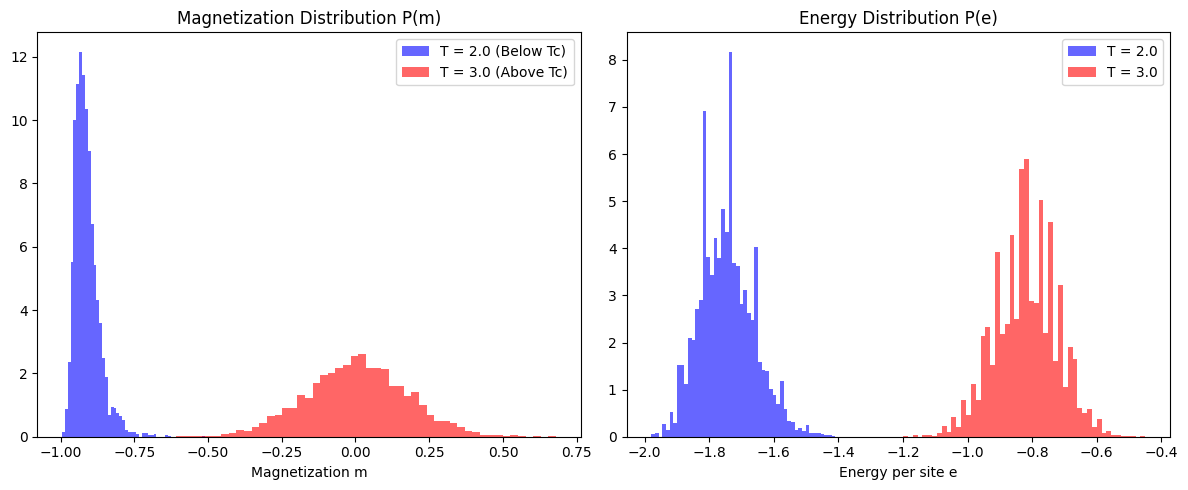

In [10]:
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))

# Magnetization Histogram
ax1.hist(M_low, bins = 50, alpha = 0.6, label = f'T = {T_low} (Below Tc)', color = 'blue', density = True)
ax1.hist(M_high, bins = 50, alpha = 0.6, label = f'T = {T_high} (Above Tc)', color = 'red', density = True)
ax1.set_title("Magnetization Distribution P(m)")
ax1.set_xlabel("Magnetization m")
ax1.legend()

# Energy Histogram
ax2.hist(E_low, bins = 50, alpha = 0.6, label = f'T = {T_low}', color = 'blue', density = True)
ax2.hist(E_high, bins = 50, alpha = 0.6, label = f'T = {T_high}', color = 'red', density = True)
ax2.set_title("Energy Distribution P(e)")
ax2.set_xlabel("Energy per site e")
ax2.legend()

plt.tight_layout()
plt.show()

### Question 4

In [11]:
def run_simulation_at_T(N, T, eq_steps = 2000, mc_steps = 10000, skip = 50):
    beta = 1.0 / T
    J = 1.0
    lattice = initialize_lattice(N, state = 'up')
    
    # 1. Equilibrate
    for _ in range(eq_steps):
        metropolis_step_efficient(lattice, beta, J)
        
    # 2. Measurement Phase
    current_energy = calculate_energy(lattice, J)
    energies = []
    magnets = []
    
    for s in range(mc_steps):
        lattice, dE_step = metropolis_step_efficient(lattice, beta, J)
        current_energy += dE_step
        
        if s % skip == 0:
            energies.append(current_energy)
            magnets.append(np.sum(lattice))
            
    # Calculate Observables
    E = np.array(energies)
    M = np.abs(np.array(magnets)) # Use |M| for finite systems
    n_sites = N**2
    
    avg_m = np.mean(M) / n_sites
    susceptibility = (np.var(M)) / (n_sites * T)
    specific_heat = (np.var(E)) / (n_sites * T**2)
    
    return avg_m, susceptibility, specific_heat

In [12]:
N = 20  # Lattice size
temperatures = np.linspace(0.2, 4, 20) # Range containing Tc ~ 2.27
M_list, Chi_list, Cv_list = [], [], []

print(f"Simulating N={N}...")
for T in temperatures:
    m, chi, cv = run_simulation_at_T(N, T)
    M_list.append(m)
    Chi_list.append(chi)
    Cv_list.append(cv)

Simulating N=20...


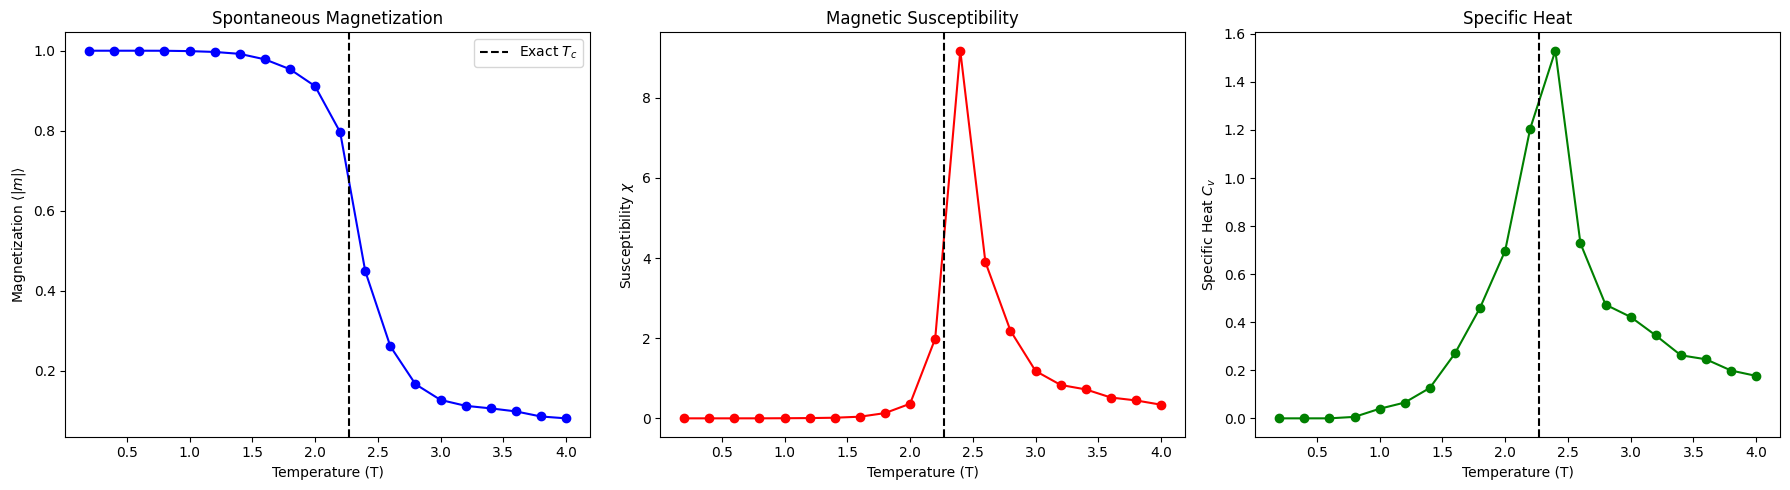

In [13]:
# Plotting 
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (18, 5))

# Magnetization 
ax1.plot(temperatures, M_list, 'o-', color = 'blue')
ax1.axvline(x = 2.269, color = 'black', linestyle = '--', label = r'Exact $T_c$')
ax1.set_xlabel("Temperature (T)")
ax1.set_ylabel(r"Magnetization $\langle|m|\rangle$") 
ax1.set_title("Spontaneous Magnetization")
ax1.legend()

# Susceptibility 
ax2.plot(temperatures, Chi_list, 'o-', color = 'red')
ax2.axvline(x = 2.269, color = 'black', linestyle = '--')
ax2.set_xlabel("Temperature (T)")
ax2.set_ylabel(r"Susceptibility $\chi$") 
ax2.set_title("Magnetic Susceptibility")

# Specific Heat
ax3.plot(temperatures, Cv_list, 'o-', color = 'green')
ax3.axvline(x = 2.269, color = 'black', linestyle = '--')
ax3.set_xlabel("Temperature (T)")
ax3.set_ylabel(r"Specific Heat $C_v$")
ax3.set_title("Specific Heat")

plt.tight_layout()
plt.show()

### Question 5

In [14]:
idx_max = np.argmax(Chi_list)
Tc = temperatures[idx_max]

print(f"Numerical estimate for Tc: {Tc}")

Numerical estimate for Tc: 2.4


In [15]:
# Example: Selecting points for Gamma (above Tc)
# We pick points where T is between Tc and Tc + 0.5
mask_above = (temperatures > Tc) & (temperatures < Tc + 1)
mask_below = (temperatures > Tc - 1) & (temperatures < Tc)

T_pts_above = temperatures[mask_above]
Chi_pts_above = np.array(Chi_list)[mask_above]

T_pts_below = temperatures[mask_below]
Chi_pts_below = np.array(Chi_list)[mask_below]

In [16]:
# 1. Calculate reduced temperature t = |T - Tc| / Tc
t_values_above = np.abs((T_pts_above - Tc) / Tc)
t_values_below = np.abs((T_pts_below - Tc) / Tc)

# 2. Filter out any zeros to avoid log(0) errors
valid = t_values_above > 0
log_t_above = np.log(t_values_above[valid])
log_chi_above = np.log(Chi_pts_above[valid])

log_t_below = np.log(t_values_below[valid])
log_chi_below = np.log(Chi_pts_below[valid])

# 3. Linear Regression: ln(chi) = -gamma * ln(t) + C
slope_above, intercept_above, r_value_above, p_value_above, std_err_above = linregress(log_t_above, log_chi_above)
slope_below, intercept_below, r_value_below, p_value_below, std_err_below = linregress(log_t_below, log_chi_below)

# The slope of the log-log plot gives you the exponent
gamma_calc_above = -slope_above 
gamma_calc_below = -slope_below

print(f"Calculated Gamma from above: {gamma_calc_above:.4f}")
print(f"Calculated Gamma from below: {gamma_calc_below:.4f}")

Calculated Gamma from above: 1.1234
Calculated Gamma from below: 2.7233


In [17]:
# Select points below Tc
mask_beta_below = (temperatures < Tc) & (temperatures > Tc - 0.6)
t_beta_below = np.abs((temperatures[mask_beta_below] - Tc) / Tc)
m_pts_below = np.array(M_list)[mask_beta_below]

# Select points above Tc
mask_beta_above = (temperatures < Tc + 0.6) & (temperatures > Tc)
t_beta_above = np.abs((temperatures[mask_beta_above] - Tc) / Tc)
m_pts_above = np.array(M_list)[mask_beta_above]

# Fit: ln(m) = beta * ln|t| + C
slope_beta_below, _, r_beta_below, _, _ = linregress(np.log(t_beta_below), np.log(m_pts_below))
slope_beta_above, _, r_beta_above, _, _ = linregress(np.log(t_beta_above), np.log(m_pts_above))
print(f"Calculated Beta from below: {slope_beta_below:.4f}")
print(f"Calculated Beta from above: {slope_beta_above:.4f}")

Calculated Beta from below: 0.1948
Calculated Beta from above: -0.6516


In [18]:
def calculate_correlation_function(lattice):
    N = lattice.shape[0]
    max_r = N // 2
    G = np.zeros(max_r)
    
    # Calculated average <Si>
    avg_s = np.mean(lattice)
    
    # We iterate over distances r
    for r in range(max_r):
        # Calculated <Si * Si+r> averaged over the whole lattice
        # We check correlations in both x and y directions for better statistics
        corr_x = np.mean(lattice * np.roll(lattice, -r, axis=1))
        corr_y = np.mean(lattice * np.roll(lattice, -r, axis=0))
        
        G[r] = (corr_x + corr_y) / 2.0 - avg_s**2
        
    return G

In [19]:
N_large = 32 
T_crit = Tc
beta_crit = 1.0 / T_crit

lattice = initialize_lattice(N_large, state = 'up')
# Long equilibration for the large lattice
for _ in range(5000): metropolis_step_efficient(lattice, beta_crit)

all_G = []
for s in range(2000):
    lattice, _ = metropolis_step_efficient(lattice, beta_crit)
    if s % 20 == 0:
        all_G.append(calculate_correlation_function(lattice))

avg_G = np.mean(all_G, axis = 0)
r_values = np.arange(len(avg_G))

In [20]:
# 1. Ensure G_fit only contains positive values
mask = avg_G > 0
r_valid = r_values[mask]
G_valid = avg_G[mask]

# 2. Focussing on small to mid r (avoid the noisy boundary at r ~ N/2)
# For N = 32, r between 1 and 8 is usually the 'clean' region
fit_range = (r_valid >= 1) & (r_valid <= N_large // 8)
r_final = r_valid[fit_range]
G_final = G_valid[fit_range]

if len(r_final) > 2:
    slope_eta, _, r_val, _, _ = linregress(np.log(r_final), np.log(G_final))
    calculated_eta = -slope_eta
    print(f"Calculated Eta: {calculated_eta:.4f}")
else:
    print("Error: Not enough positive data points in the fit range. Increase mc_steps!")

Calculated Eta: 0.7758


### Question 6

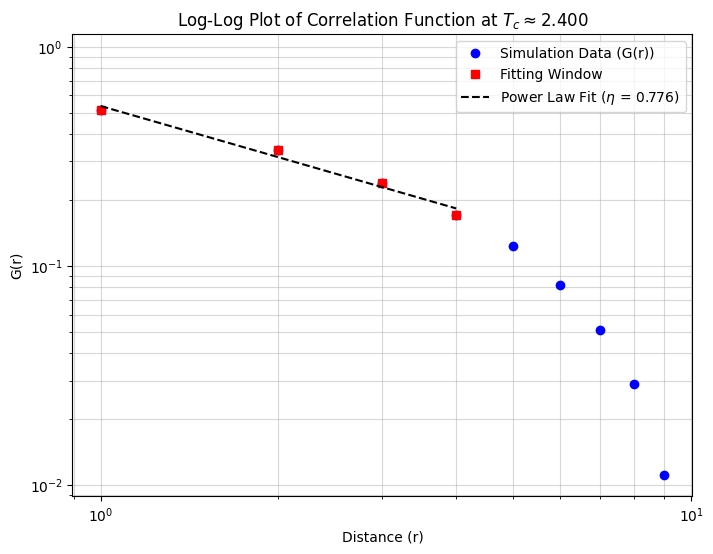

In [21]:
slope_eta, intercept, r_val, _, _ = linregress(np.log(r_final), np.log(G_final))

# Plotting the raw data and the fit
plt.figure(figsize = (8, 6))

# Plotting all positive G(r) points
plt.loglog(r_valid, G_valid, 'ob', label = 'Simulation Data (G(r))')

# Plot the points used in the fit (r = 1 to N/8)
plt.loglog(r_final, G_final, 'sr', label = 'Fitting Window')

# Generating the fit line: G = exp(intercept) * r^(-eta)
fit_line = np.exp(intercept) * r_final**(slope_eta)
plt.loglog(r_final, fit_line, 'k--', label = r'Power Law Fit ($\eta$ = ' + f'{calculated_eta:.3f})')

plt.title(rf"Log-Log Plot of Correlation Function at $T_c \approx {T_crit:.3f}$")
plt.xlabel("Distance (r)")
plt.ylabel("G(r)")
plt.legend()
plt.grid(True, which = "both", ls = "-", alpha = 0.5)
plt.show()